In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [5]:
data = pd.read_csv(
    "/kaggle/input/datasets/nalisha/tesla-ea-deliveries-and-production-data20152025/tesla_deliveries_dataset_2015_2025.csv"
)


In [6]:
data

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
...,...,...,...,...,...,...,...,...,...,...,...,...
2635,2021,10,Middle East,Model Y,13488,14333,113771.10,120,719,1454.68,Official (Quarter),4273
2636,2019,7,Middle East,Model S,18300,18407,81889.67,82,487,1336.81,Official (Quarter),9833
2637,2019,9,Asia,Model S,13291,14839,97139.38,100,580,1156.32,Estimated (Region),13709
2638,2020,5,Asia,Cybertruck,3471,3714,69990.57,60,358,186.39,Interpolated (Month),6754


In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB


In [8]:
data.describe()

,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


In [9]:
# Create a Date column for time-series analysis

data["Date"] = pd.to_datetime(
    dict(year=data.Year,
         month=data.Month,
         day=1)
)

data= data.sort_values("Date").reset_index(drop=True)

In [10]:
TARGET = "Estimated_Deliveries"

In [11]:
data.info

<bound method DataFrame.info of       Year  Month         Region       Model  Estimated_Deliveries  \
0     2015      1           Asia     Model Y                 12446   
1     2015      1    Middle East     Model 3                 11446   
2     2015      1    Middle East  Cybertruck                  8803   
3     2015      1  North America  Cybertruck                  6367   
4     2015      1           Asia     Model 3                  8795   
...    ...    ...            ...         ...                   ...   
2635  2025     12           Asia     Model S                 12747   
2636  2025     12    Middle East  Cybertruck                 11972   
2637  2025     12           Asia     Model X                 13671   
2638  2025     12         Europe     Model S                 11374   
2639  2025     12    Middle East     Model X                  9319   

      Production_Units  Avg_Price_USD  Battery_Capacity_kWh  Range_km  \
0                13885       55183.13                 

In [12]:
# Missing Values

missing = data.isnull().sum().sort_values(ascending=False)

missing

Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
Date                    0
dtype: int64

In [13]:
# Duplicate Records

duplicates = data.duplicated().sum()

print(f"Duplicate Rows : {duplicates}")

Duplicate Rows : 0


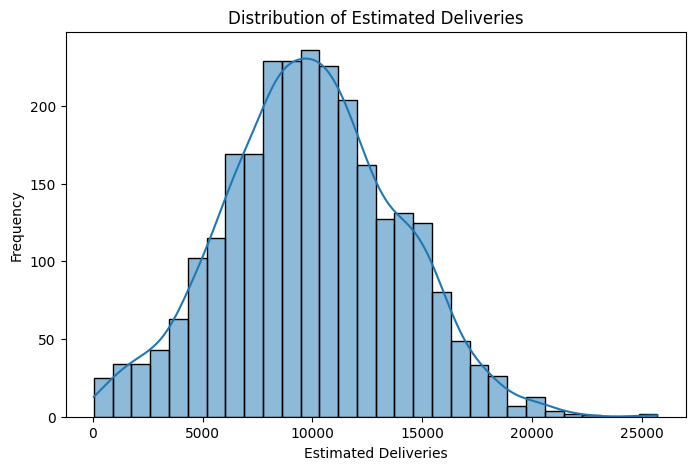

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(data["Estimated_Deliveries"], bins=30, kde=True)

plt.title("Distribution of Estimated Deliveries")
plt.xlabel("Estimated Deliveries")
plt.ylabel("Frequency")

plt.show()

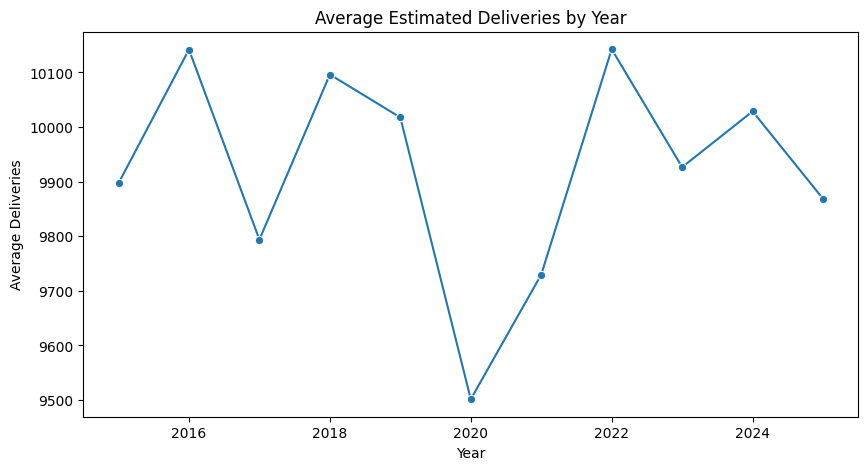

In [15]:
yearly = (
    data.groupby("Year")["Estimated_Deliveries"]
      .mean()
      .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(data=yearly,
             x="Year",
             y="Estimated_Deliveries",
             marker="o")

plt.title("Average Estimated Deliveries by Year")
plt.ylabel("Average Deliveries")

plt.show()

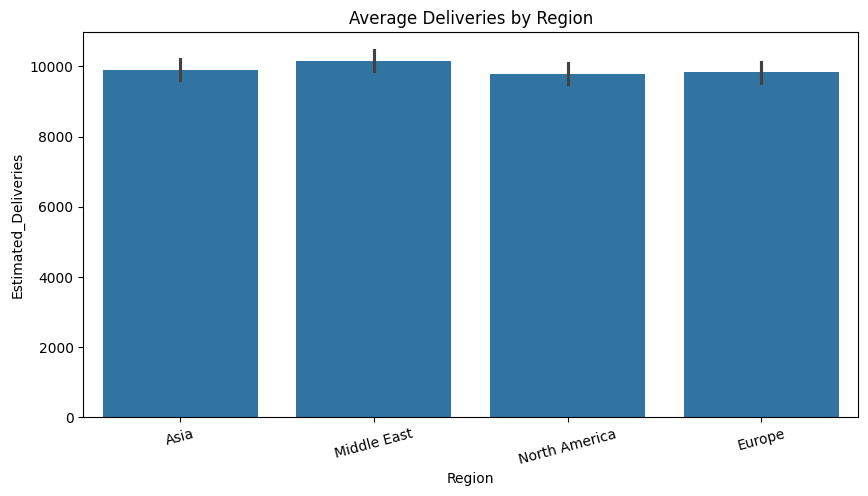

In [16]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=data,
    x="Region",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Region")

plt.xticks(rotation=15)

plt.show()

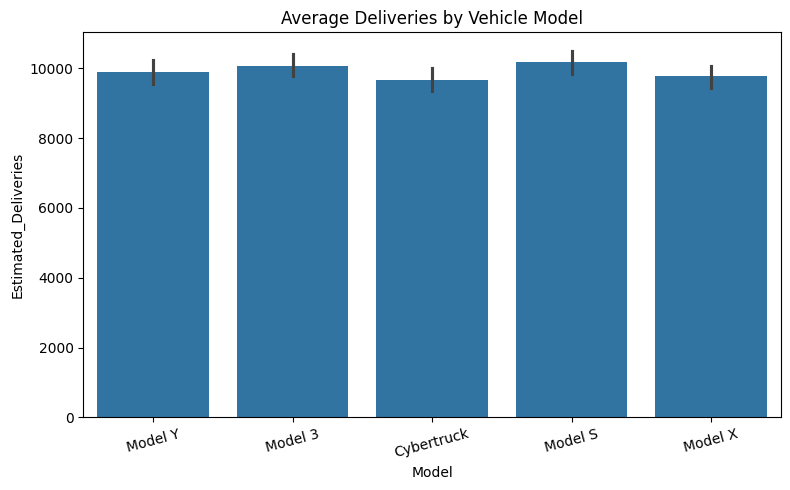

In [17]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=data,
    x="Model",
    y="Estimated_Deliveries",
    estimator=np.mean
)

plt.title("Average Deliveries by Vehicle Model")

plt.xticks(rotation=15)

plt.show()

In [18]:
yearly = (
    data.groupby("Year")["Estimated_Deliveries"]
      .sum()
      .reset_index()
)

In [19]:
region = (
    data.groupby("Region")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

In [20]:
model = (
    data.groupby("Model")["Estimated_Deliveries"]
      .sum()
      .sort_values(ascending=False)
)

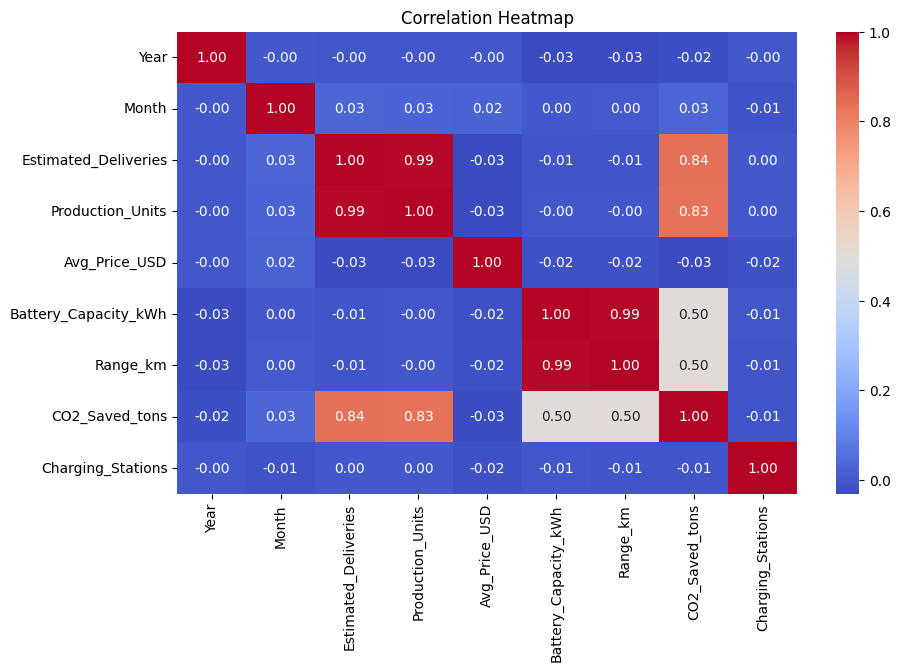

In [21]:
plt.figure(figsize=(10, 6))

corr = data.select_dtypes(include=np.number).corr()

sns.heatmap(corr,
            annot=True,
            cmap="coolwarm",
            fmt=".2f")

plt.title("Correlation Heatmap")
plt.show()

"I noticed that Battery_Capacity_kWh and Range_km have a correlation of 0.99, indicating multicollinearity. Since highly correlated features can affect the stability and interpretability of linear regression coefficients, I would consider dropping one of them or using Ridge Regression, which is more robust to multicollinearity."

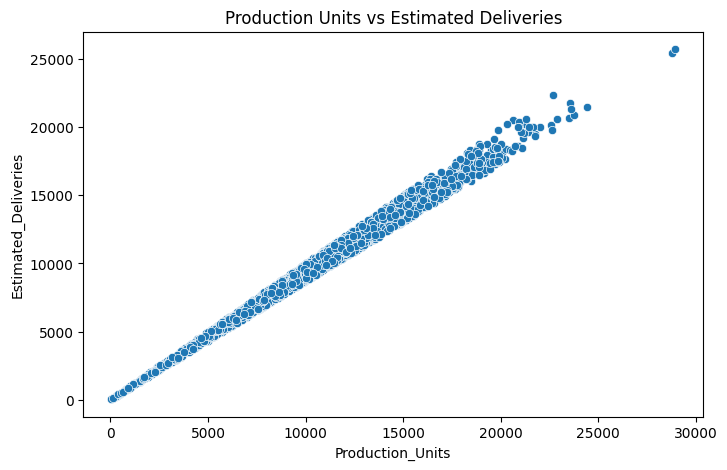

In [22]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=data,
    x="Production_Units",
    y="Estimated_Deliveries"
)

plt.title("Production Units vs Estimated Deliveries")
plt.show()

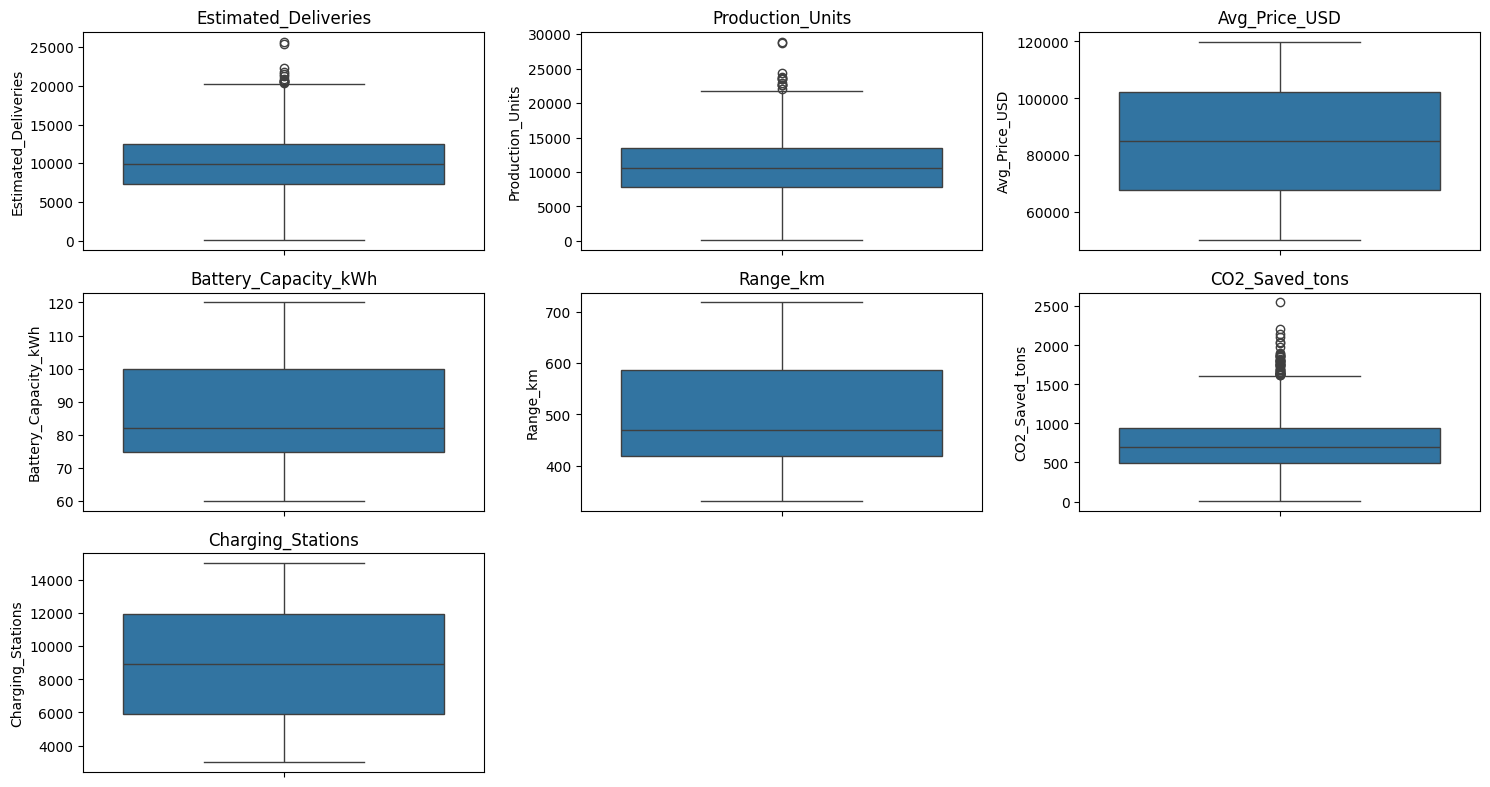

In [23]:
numerical_cols = [
    "Estimated_Deliveries",
    "Production_Units",
    "Avg_Price_USD",
    "Battery_Capacity_kWh",
    "Range_km",
    "CO2_Saved_tons",
    "Charging_Stations"
]

plt.figure(figsize=(15,8))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3,3,i)
    sns.boxplot(y=data[col])
    plt.title(col)

plt.tight_layout()
plt.show()

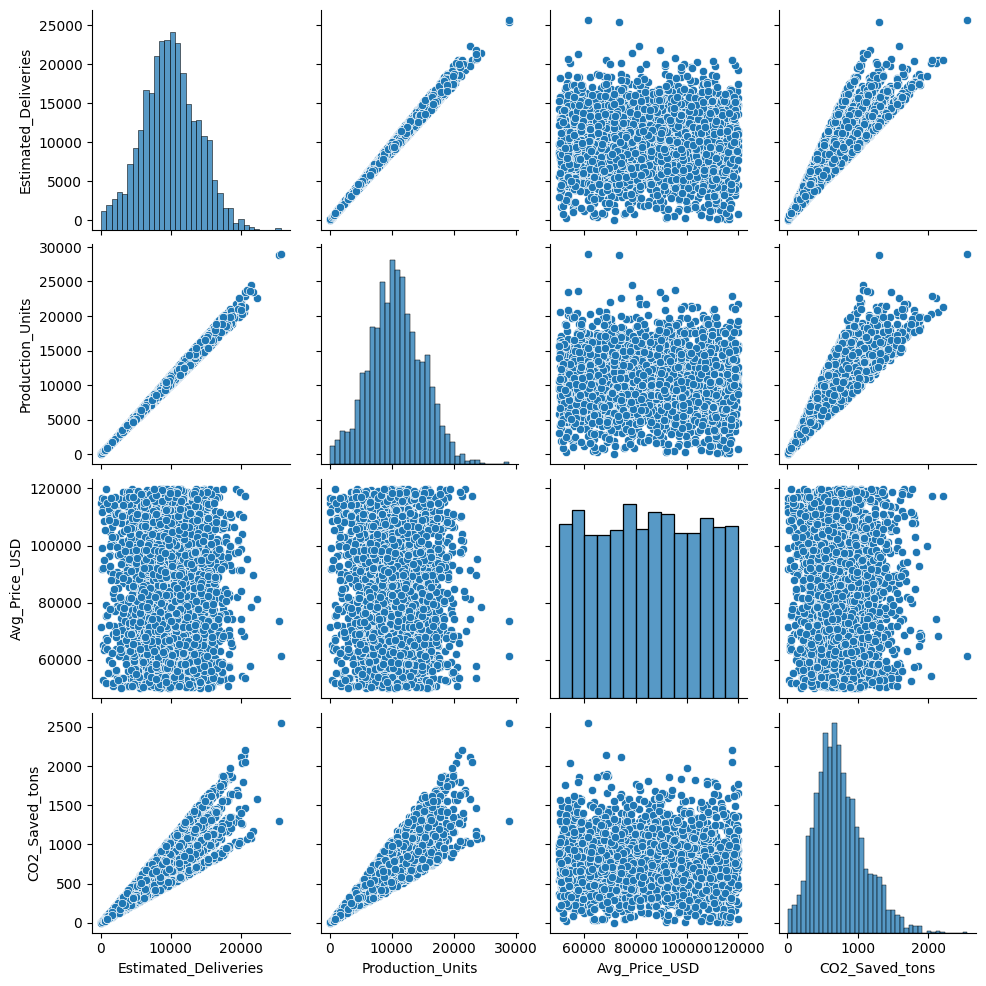

In [24]:
sns.pairplot(
    data[[
        "Estimated_Deliveries",
        "Production_Units",
        "Avg_Price_USD",
        "CO2_Saved_tons"
    ]]
)

plt.show()

In [25]:
# Quarter

data["Quarter"] = ((data["Month"] - 1) // 3) + 1

# Month Name

data["Month_Name"] = data["Date"].dt.month_name()

data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name
0,2015,1,Asia,Model Y,12446,13885,55183.13,60,340,634.75,Official (Quarter),4390,2015-01-01,1,January
1,2015,1,Middle East,Model 3,11446,12752,89289.40,100,588,1009.54,Estimated (Region),8925,2015-01-01,1,January
2,2015,1,Middle East,Cybertruck,8803,9344,102888.58,60,336,443.67,Interpolated (Month),3923,2015-01-01,1,January
3,2015,1,North America,Cybertruck,6367,6802,104962.32,82,459,438.37,Estimated (Region),9170,2015-01-01,1,January
4,2015,1,Asia,Model 3,8795,9165,87988.73,82,456,601.58,Official (Quarter),12626,2015-01-01,1,January


In [26]:
data["Production_Efficiency"] = (
    data["Estimated_Deliveries"] /
    data["Production_Units"]
)

In [27]:
data = data.sort_values(["Region", "Model", "Date"])

data["Lag_1_Deliveries"] = (
    data.groupby(["Region", "Model"])["Estimated_Deliveries"]
        .shift(1)
)

In [28]:
data["Rolling_Mean_3"] = (
    data["Estimated_Deliveries"]
    .rolling(window=3)
    .mean()
)

In [29]:
data["Delivery_Growth"] = (
    data["Estimated_Deliveries"]
    .pct_change()
)

In [30]:
data.head(10)

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,Month_Name,Production_Efficiency,Lag_1_Deliveries,Rolling_Mean_3,Delivery_Growth
12,2015,1,Asia,Cybertruck,11325,11887,54449.08,60,339,575.88,Estimated (Region),6902,2015-01-01,1,January,0.952721,NaN,NaN,NaN
33,2015,2,Asia,Cybertruck,13254,14878,88864.06,75,432,858.86,Estimated (Region),5902,2015-02-01,1,February,0.890846,11325.0,NaN,0.170331
48,2015,3,Asia,Cybertruck,10257,11441,65107.47,100,581,893.90,Interpolated (Month),4024,2015-03-01,1,March,0.896513,13254.0,11612.000000,-0.226120
75,2015,4,Asia,Cybertruck,15221,15951,112686.63,60,341,778.55,Estimated (Region),3130,2015-04-01,2,April,0.954235,10257.0,12910.666667,0.483962
85,2015,5,Asia,Cybertruck,6406,7281,107577.61,75,448,430.48,Interpolated (Month),11708,2015-05-01,2,May,0.879824,15221.0,10628.000000,-0.579134
110,2015,6,Asia,Cybertruck,7201,8144,114461.07,75,414,447.18,Estimated (Region),6322,2015-06-01,2,June,0.884209,6406.0,9609.333333,0.124102
123,2015,7,Asia,Cybertruck,113,118,115067.04,120,709,12.02,Interpolated (Month),14580,2015-07-01,3,July,0.957627,7201.0,4573.333333,-0.984308
152,2015,8,Asia,Cybertruck,10222,11128,77930.19,60,331,507.52,Official (Quarter),7022,2015-08-01,3,August,0.918584,113.0,5845.333333,89.460177
170,2015,9,Asia,Cybertruck,10844,12086,59807.92,60,356,579.07,Interpolated (Month),8849,2015-09-01,3,September,0.897236,10222.0,7059.666667,0.060849
196,2015,10,Asia,Cybertruck,5675,6461,117974.08,120,716,609.49,Estimated (Region),8690,2015-10-01,4,October,0.878347,10844.0,8913.666667,-0.476669


In [31]:
data = data.dropna().reset_index(drop=True)

print(data.shape)

(2619, 19)


In [32]:
TARGET = "Estimated_Deliveries"

X = data.drop(columns=[TARGET])

y = data[TARGET]

In [33]:
X = X.drop(columns=["Date"])

In [34]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()

numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print("Categorical Columns:")
print(categorical_cols)

print("\nNumerical Columns:")
print(numerical_cols)

Categorical Columns:
['Region', 'Model', 'Source_Type', 'Month_Name']

Numerical Columns:
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Production_Efficiency', 'Lag_1_Deliveries', 'Rolling_Mean_3', 'Delivery_Growth']


In [35]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [36]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [37]:
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)

print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (2095, 17)
X_test : (524, 17)
y_train: (2095,)
y_test : (524,)


In [38]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

In [39]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    r2 = r2_score(y_true, y_pred)

    print("="*40)
    print(model_name)
    print("="*40)

    print(f"MAE : {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    print(f"R²  : {r2:.4f}")

    return [model_name, mae, rmse, r2]

In [40]:
linear_results = evaluate_model(
    y_test,
    linear_pred,
    "Linear Regression"
)

Linear Regression
MAE : 106.11
RMSE: 153.29
R²  : 0.9984


In [41]:
from sklearn.linear_model import Ridge

ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)

In [42]:
ridge_results = evaluate_model(
    y_test,
    ridge_pred,
    "Ridge Regression"
)

Ridge Regression
MAE : 106.03
RMSE: 153.86
R²  : 0.9984


In [43]:
from sklearn.linear_model import Lasso

lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=0.1))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)

In [44]:
lasso_results = evaluate_model(
    y_test,
    lasso_pred,
    "Lasso Regression"
)

Lasso Regression
MAE : 105.81
RMSE: 152.81
R²  : 0.9984


In [45]:
results = pd.DataFrame(
    [
        linear_results,
        ridge_results,
        lasso_results
    ],
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,106.106028,153.290467,0.998439
1,Ridge Regression,106.026253,153.856335,0.998427
2,Lasso Regression,105.809723,152.808810,0.998449


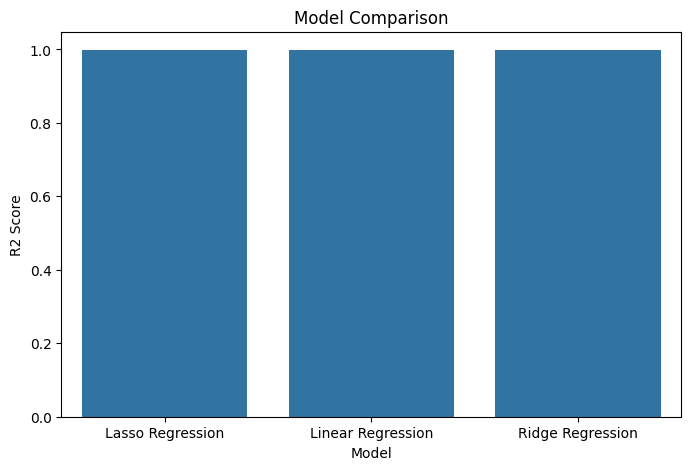

In [46]:
results.sort_values(
    "R2 Score",
    ascending=False,
    inplace=True
)

plt.figure(figsize=(8,5))

sns.barplot(
    data=results,
    x="Model",
    y="R2 Score"
)

plt.title("Model Comparison")

plt.show()

Although all three regression models achieved an R² score of approximately 0.998, this is largely due to the very strong linear relationship between Production Units and Estimated Deliveries. Since the dataset is synthetic and the predictor is highly correlated with the target, even a simple Linear Regression performs exceptionally well. Regularization through Ridge and Lasso results in only marginal performance differences.

In [47]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

In [48]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import cross_val_score, GridSearchCV

In [49]:
TARGET = "Estimated_Deliveries"

X = data.drop(columns=[TARGET, "Date"])
y = data[TARGET]

In [50]:
categorical_cols = X.select_dtypes(include="object").columns.tolist()
numerical_cols = X.select_dtypes(exclude="object").columns.tolist()

print(categorical_cols)
print(numerical_cols)

['Region', 'Model', 'Source_Type', 'Month_Name']
['Year', 'Month', 'Production_Units', 'Avg_Price_USD', 'Battery_Capacity_kWh', 'Range_km', 'CO2_Saved_tons', 'Charging_Stations', 'Quarter', 'Production_Efficiency', 'Lag_1_Deliveries', 'Rolling_Mean_3', 'Delivery_Growth']


In [51]:
split = int(len(data) * 0.8)

X_train = X.iloc[:split]
X_test = X.iloc[split:]

y_train = y.iloc[:split]
y_test = y.iloc[split:]

In [52]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_cols),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_cols)
    ]
)

In [53]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_pipeline.fit(X_train, y_train)

linear_pred = linear_pipeline.predict(X_test)

In [54]:
def evaluate_model(y_true, y_pred, model_name):

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    print("=" * 40)
    print(model_name)
    print("=" * 40)
    print("MAE :", round(mae,2))
    print("RMSE:", round(rmse,2))
    print("R2  :", round(r2,4))

    return [model_name, mae, rmse, r2]

In [55]:
linear_results = evaluate_model(
    y_test,
    linear_pred,
    "Linear Regression"
)

Linear Regression
MAE : 106.11
RMSE: 153.29
R2  : 0.9984


In [56]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1))
])

ridge_pipeline.fit(X_train, y_train)

ridge_pred = ridge_pipeline.predict(X_test)

ridge_results = evaluate_model(
    y_test,
    ridge_pred,
    "Ridge Regression"
)

Ridge Regression
MAE : 106.03
RMSE: 153.86
R2  : 0.9984


In [62]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(
        alpha=0.1,
        max_iter=10000,
        random_state=42
    ))
])

lasso_pipeline.fit(X_train, y_train)

lasso_pred = lasso_pipeline.predict(X_test)

lasso_results = evaluate_model(
    y_test,
    lasso_pred,
    "Lasso Regression"
)

Lasso Regression
MAE : 105.81
RMSE: 152.81
R2  : 0.9984


In [63]:
results = pd.DataFrame(
    [
        linear_results,
        ridge_results,
        lasso_results
    ],
    columns=[
        "Model",
        "MAE",
        "RMSE",
        "R2 Score"
    ]
)

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,106.106028,153.290467,0.998439
1,Ridge Regression,106.026253,153.856335,0.998427
2,Lasso Regression,105.809723,152.808810,0.998449


In [59]:
for name, model in [
    ("Linear", linear_pipeline),
    ("Ridge", ridge_pipeline),
    ("Lasso", lasso_pipeline)
]:

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2"
    )

    print(f"{name} CV Scores: {scores}")
    print(f"{name} Mean R²: {scores.mean():.4f}")
    print("-"*50)

Linear CV Scores: [0.99852776 0.99832655 0.9981741  0.99855615 0.99829821]
Linear Mean R²: 0.9984
--------------------------------------------------
Ridge CV Scores: [0.99854254 0.99833133 0.99817916 0.99853545 0.99827848]
Ridge Mean R²: 0.9984
--------------------------------------------------
Lasso CV Scores: [0.99852942 0.99832896 0.99818074 0.99855967 0.99829936]
Lasso Mean R²: 0.9984
--------------------------------------------------


In [64]:
ridge_params = {
    "model__alpha":[0.01,0.1,1,10,100]
}

ridge_grid = GridSearchCV(
    ridge_pipeline,
    ridge_params,
    cv=5,
    scoring="r2"
)

ridge_grid.fit(X_train,y_train)

print("Best Alpha:",ridge_grid.best_params_)
print("Best CV Score:",ridge_grid.best_score_)

Best Alpha: {'model__alpha': 0.1}
Best CV Score: 0.998376759390123


In [66]:
lasso_params = {
    "model__alpha": [0.0001, 0.001, 0.01, 0.1, 1]
}

lasso_grid = GridSearchCV(
    estimator=Pipeline([
        ("preprocessor", preprocessor),
        ("model", Lasso(max_iter=10000, random_state=42))
    ]),
    param_grid=lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Alpha:", lasso_grid.best_params_)
print("Best CV Score:", lasso_grid.best_score_)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.339e+07, tolerance: 2.641e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.274e+07, tolerance: 2.602e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.541e+06, tolerance: 2.671e

Best Alpha: {'model__alpha': 1}
Best CV Score: 0.9983940541418477


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.008e+07, tolerance: 2.602e+06
  model = cd_fast.enet_coordinate_descent(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.086e+07, tolerance: 2.634e+06
  model = cd_fast.enet_coordinate_descent(


In [67]:
monthly = (
    data.groupby("Date")["Estimated_Deliveries"]
    .sum()
    .reset_index()
)

monthly.head()


,Date,Estimated_Deliveries
0,2015-02-01,151799
1,2015-03-01,184567
2,2015-04-01,225623
3,2015-05-01,184264
4,2015-06-01,198787


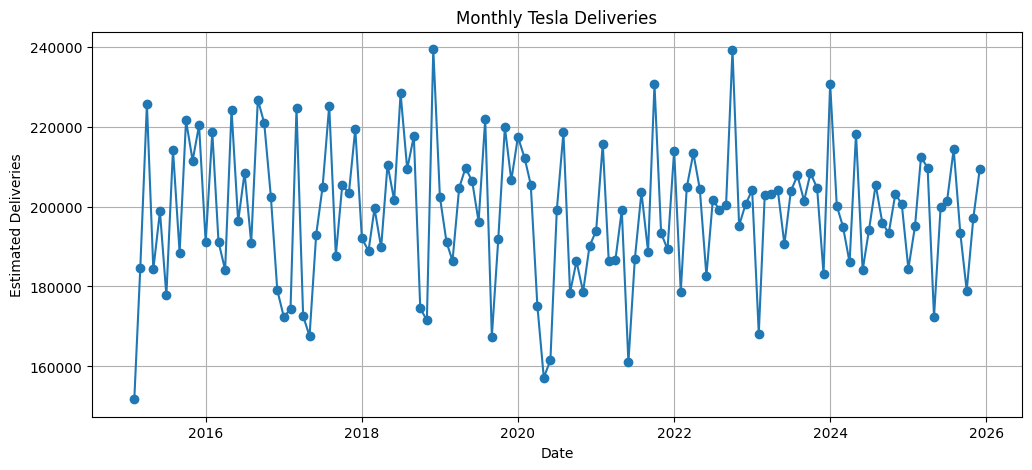

In [68]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Date"],
    monthly["Estimated_Deliveries"],
    marker="o"
)

plt.title("Monthly Tesla Deliveries")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")

plt.grid(True)

plt.show()

In [69]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(monthly["Estimated_Deliveries"])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -9.044856842624792
p-value: 5.018669779631601e-15


In [70]:
if result[1] < 0.05:
    print("The series is stationary.")
else:
    print("The series is NOT stationary.")

The series is stationary.


In [71]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(
    monthly["Estimated_Deliveries"],
    order=(1,1,1)
)

model_fit = model.fit()

print(model_fit.summary())

                                SARIMAX Results                                 
Dep. Variable:     Estimated_Deliveries   No. Observations:                  131
Model:                   ARIMA(1, 1, 1)   Log Likelihood               -1482.544
Date:                  Sun, 28 Jun 2026   AIC                           2971.088
Time:                          18:30:19   BIC                           2979.691
Sample:                               0   HQIC                          2974.583
                                  - 131                                         
Covariance Type:                    opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.4099      0.079      5.163      0.000       0.254       0.566
ma.L1         -1.0000      0.111     -8.975      0.000      -1.218      -0.782
sigma2      4.576e+08   2.44e-10   1

In [72]:
forecast = model_fit.forecast(steps=12)

forecast

131    201489.406282
132    198250.185133
133    196922.281671
134    196377.913898
135    196154.752892
136    196063.269088
137    196025.765733
138    196010.391409
139    196004.088778
140    196001.505043
141    196000.445854
142    196000.011644
Name: predicted_mean, dtype: float64

In [73]:
future_dates = pd.date_range(
    start=monthly["Date"].max() + pd.DateOffset(months=1),
    periods=12,
    freq="MS"
)

forecast_df = pd.DataFrame({
    "Date": future_dates,
    "Forecast": forecast
})

forecast_df

,Date,Forecast
131,2026-01-01,201489.406282
132,2026-02-01,198250.185133
133,2026-03-01,196922.281671
134,2026-04-01,196377.913898
135,2026-05-01,196154.752892
136,2026-06-01,196063.269088
137,2026-07-01,196025.765733
138,2026-08-01,196010.391409
139,2026-09-01,196004.088778
140,2026-10-01,196001.505043


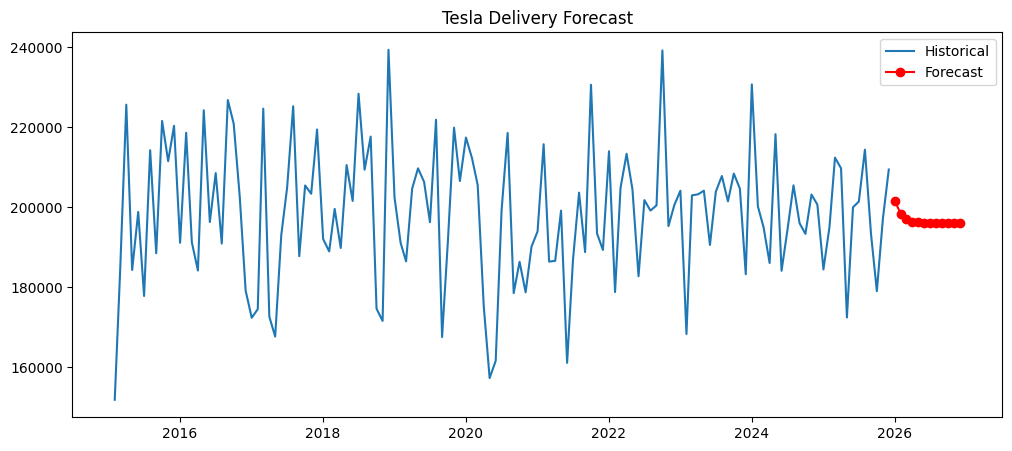

In [74]:
plt.figure(figsize=(12,5))

plt.plot(
    monthly["Date"],
    monthly["Estimated_Deliveries"],
    label="Historical"
)

plt.plot(
    forecast_df["Date"],
    forecast_df["Forecast"],
    color="red",
    marker="o",
    label="Forecast"
)

plt.legend()

plt.title("Tesla Delivery Forecast")

plt.show()